In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =  pd.read_csv("/home/kepha/healthcare-ml/data/raw/healthcare_raw_backup.csv")

In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [6]:
# Convert to datetime
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Calculate days hospitalized
df['Days_Hospitalized'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Check for anomalies (negative days)
print(f"Minimum stay: {df['Days_Hospitalized'].min()} days")

Minimum stay: 1 days


/tmp/ipykernel_21011/1390079156.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Test Results', palette='viridis')


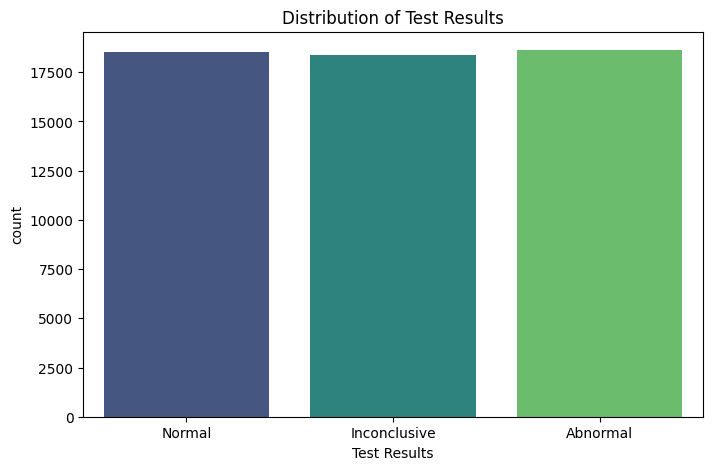

Test Results
Abnormal        0.335622
Normal          0.333640
Inconclusive    0.330739
Name: proportion, dtype: float64


In [9]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Test Results', palette='viridis')
plt.title('Distribution of Test Results')
plt.show()

print(df['Test Results'].value_counts(normalize=True))

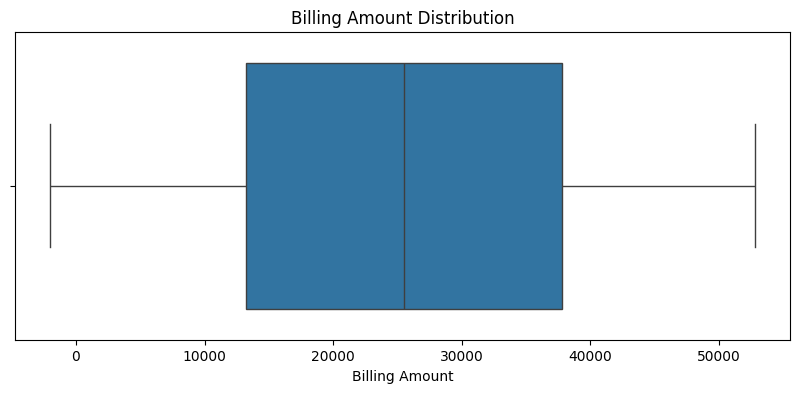

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64


In [11]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Billing Amount'])
plt.title('Billing Amount Distribution')
plt.show()

print(df['Billing Amount'].describe())

In [12]:
print("Unique Results:", df['Test Results'].unique())
print("\nValue Counts:\n", df['Test Results'].value_counts())

Unique Results: <StringArray>
['Normal', 'Inconclusive', 'Abnormal']
Length: 3, dtype: str

Value Counts:
 Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


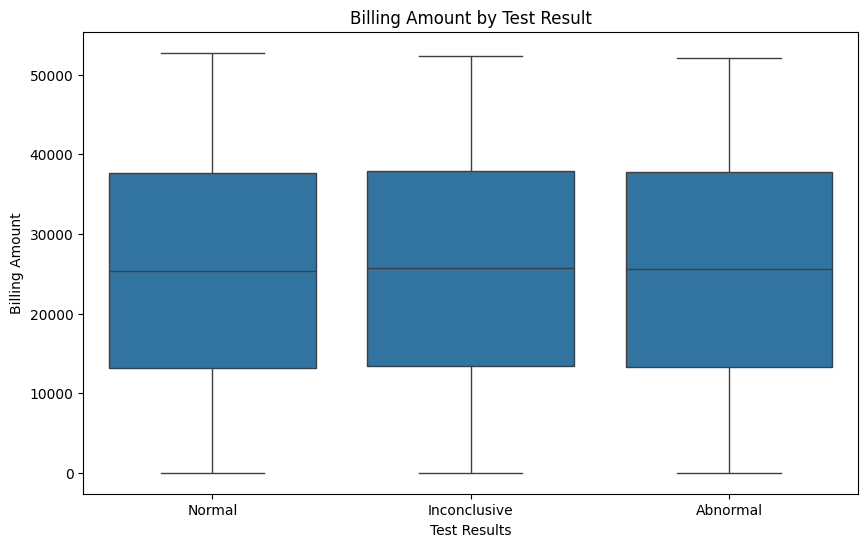

In [13]:
# 1. Fix Negative Billing (Set to 0 or absolute value)
# Let's use absolute value assuming it was just a sign error
df['Billing Amount'] = df['Billing Amount'].abs()

# 2. Check how Billing Amount correlates with Test Results (Boxplot)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Test Results', y='Billing Amount')
plt.title('Billing Amount by Test Result')
plt.show()

In [ ]:
# Check unique counts for all object columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].nunique() < 10:
        print(f"Values: {df[col].unique()}\n")

In [15]:
# Create a cross-tabulation to see the relationship
pd.crosstab(df['Medical Condition'], df['Medication'])

Medication,Aspirin,Ibuprofen,Lipitor,Paracetamol,Penicillin
Medical Condition,,,,,
Arthritis,1918,1822,1825,1877,1866
Asthma,1802,1827,1823,1888,1845
Cancer,1786,1873,1922,1853,1793
Diabetes,1858,1861,1893,1811,1881
Hypertension,1865,1893,1848,1849,1790
Obesity,1865,1851,1829,1793,1893
